# **Práctica 1:** Red neuronal convolucional para clasificación de imágenes

In [ ]:
pip install optuna

**Uso de librerías**

In [ ]:
import os
import zipfile
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import nn, optim
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import optuna
import copy
import torchvision
from torchvision import models


**Descompresión de un Archivo ZIP y Preparación de Datos**  
Este código descomprime un archivo ZIP que contiene los datos del dataset escogido, verificando primero si el directorio de extracción ya existe. Si no, utiliza la librería zipfile para extraer el contenido en la ubicación especificada, preparando los datos para su uso posterior

In [ ]:
zip_path = "/content/SplitDataset.zip"
extract_dir = "/content/SplitDataset"

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

**Preprocesamiento y Carga de Datos para Entrenamiento de una Red Neuronal**  
Este código realiza el preprocesamiento y carga de datos para entrenar una red neuronal. Primero, define una serie de transformaciones (como redimensionar, rotación aleatoria, normalización) para preparar las imágenes de entrada. Luego, carga el conjunto de datos SplitDataset desde las carpetas especificadas (train, valid, test), aplicando las transformaciones definidas. Posteriormente, utiliza DataLoader para organizar los datos en lotes para el entrenamiento, validación y prueba. Finalmente, imprime el número de imágenes en cada conjunto de datos.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.ImageFolder(root='/content/SplitDataset/SplitDataset/SplitDataset/train', transform=transform)
valid_data = datasets.ImageFolder(root='/content/SplitDataset/SplitDataset/SplitDataset/valid',transform=transform)
test_data = datasets.ImageFolder(root='/content/SplitDataset/SplitDataset/SplitDataset/test', transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=64)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

train_count = len(train_data)
valid_count = len(valid_data)
test_count = len(test_data)

print(f"Número de imágenes:")
print(f"- Entrenamiento: {train_count}")
print(f"- Validación: {valid_count}")
print(f"- Prueba: {test_count}")

Número de imágenes:
- Entrenamiento: 2400
- Validación: 800
- Prueba: 800


**Aumento de Datos (Opcional)**  
Este código aplica técnicas de aumento de datos a un conjunto de imágenes para mejorar el entrenamiento de un modelo de clasificación de imágenes. Primero, define transformaciones como giros horizontales y verticales aleatorios, ajustes de brillo y contraste, y la conversión a tensores. Luego, carga un conjunto de imágenes originales de distintas clases (enfermedades y condiciones de las plantas). Para cada clase, genera 25 imágenes aumentadas y las guarda en las carpetas correspondientes. Después, imprime el número de imágenes antes y después de aplicar el aumento de datos, lo que permite verificar la efectividad del proceso.

In [ ]:
transformaciones = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor()
])

imagen_path_anthracnose = '/content/SplitDataset/SplitDataset/SplitDataset/train/Anthracnose/20211008_124250 (Custom).jpg'
imagen_path_bacterial = '/content/SplitDataset/SplitDataset/SplitDataset/train/Bacterial Canker/IMG_20211106_120807 (Custom).jpg'
imagen_path_cutting = '/content/SplitDataset/SplitDataset/SplitDataset/train/Cutting Weevil/20211011_131101 (Custom).jpg'
imagen_path_dieBack = '/content/SplitDataset/SplitDataset/SplitDataset/train/Die Back/20211129_160428 (Custom).jpg'
imagen_path_gall = '/content/SplitDataset/SplitDataset/SplitDataset/train/Gall Midge/IMG_20211106_161101 (Custom).jpg'
imagen_path_healthy = '/content/SplitDataset/SplitDataset/SplitDataset/train/Healthy/20211231_123123 (Custom).jpg'
imagen_path_powdery = '/content/SplitDataset/SplitDataset/SplitDataset/train/Powdery Mildew/20211109_121218 (Custom).jpg'
imagen_path_sooty = '/content/SplitDataset/SplitDataset/SplitDataset/train/Sooty Mould/IMG_20211108_120228 (Custom).jpg'

imagenes = [
    ("Anthracnose", imagen_path_anthracnose),
    ("Bacterial Canker", imagen_path_bacterial),
    ("Cutting Weevil", imagen_path_cutting),
    ("Die Back", imagen_path_dieBack),
    ("Gall Midge", imagen_path_gall),
    ("Healthy", imagen_path_healthy),
    ("Powdery Mildew", imagen_path_powdery),
    ("Sooty Mould", imagen_path_sooty)
]

output_base = "/content/SplitDataset/SplitDataset/SplitDataset/train"

train_data = datasets.ImageFolder(root=output_base)
train_count_before = len(train_data)

print(f"Número de imágenes originales en entrenamiento antes del aumento: {train_count_before}")

for clase, img_path in imagenes:
    imagen_original = Image.open(img_path)

    output_dir = os.path.join(output_base, clase)
    os.makedirs(output_dir, exist_ok=True)

    for idx in range(25):
        imagen_aumentada = transformaciones(imagen_original)
        imagen_aumentada_np = imagen_aumentada.permute(1, 2, 0).numpy()  # Convertir a formato numpy para guardar
        imagen_aumentada_np = (imagen_aumentada_np * 255).astype(np.uint8)  # Escalar a 0-255

        imagen_aumentada_pil = Image.fromarray(imagen_aumentada_np)
        output_path = os.path.join(output_dir, f"{clase}_aumentada_{idx+1}.jpg")
        imagen_aumentada_pil.save(output_path)

    print(f"Generadas imágenes aumentadas para la clase {clase} en {output_dir}")

train_data_after = datasets.ImageFolder(root=output_base)
train_count_after = len(train_data_after)

print(f"Número de imágenes en entrenamiento después del aumento: {train_count_after}")


Número de imágenes originales en entrenamiento antes del aumento: 2400
Generadas imágenes aumentadas para la clase Anthracnose en /content/SplitDataset/SplitDataset/train/Anthracnose
Generadas imágenes aumentadas para la clase Bacterial Canker en /content/SplitDataset/SplitDataset/train/Bacterial Canker
Generadas imágenes aumentadas para la clase Cutting Weevil en /content/SplitDataset/SplitDataset/train/Cutting Weevil
Generadas imágenes aumentadas para la clase Die Back en /content/SplitDataset/SplitDataset/train/Die Back
Generadas imágenes aumentadas para la clase Gall Midge en /content/SplitDataset/SplitDataset/train/Gall Midge
Generadas imágenes aumentadas para la clase Healthy en /content/SplitDataset/SplitDataset/train/Healthy
Generadas imágenes aumentadas para la clase Powdery Mildew en /content/SplitDataset/SplitDataset/train/Powdery Mildew
Generadas imágenes aumentadas para la clase Sooty Mould en /content/SplitDataset/SplitDataset/train/Sooty Mould
Número de imágenes en entre

**Entrenamiento de Red Neuronal Convolucional con Early Stopping y Evaluación**  
Este código entrena una red neuronal convolucional (ConvNet) utilizando la técnica de early stopping para prevenir el sobreajuste durante el entrenamiento. La clase EarlyStopping monitorea la pérdida de validación y detiene el entrenamiento si la mejora es insuficiente durante un número específico de épocas (patience). El modelo se entrena por un número determinado de épocas y, al mismo tiempo, ajusta la tasa de aprendizaje usando un scheduler (StepLR). Además, calcula la precisión del modelo en los conjuntos de entrenamiento, validación y prueba, y evalúa la exactitud final en el conjunto de prueba. Si se alcanza el umbral de early stopping, el modelo carga los mejores pesos y termina el entrenamiento antes de completar todas las épocas.

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_wts = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_model_wts = copy.deepcopy(model.state_dict())

        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

        else:
            self.best_score = score
            self.best_model_wts = copy.deepcopy(model.state_dict())
            self.counter = 0


class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        self.fc1 = nn.Linear(256 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, 8)

        self.dropout = nn.Dropout(p=0.4)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool1(F.relu(self.bn2(self.conv2(x))))
        x = self.pool1(F.relu(self.bn3(self.conv3(x))))
        x = self.pool1(F.relu(self.bn4(self.conv4(x))))
        x = x.view(-1, 256 * 6 * 6)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ConvNet().to(device)

criterio = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-4)

scheduler = StepLR(opt, step_size=5, gamma=0.5)

epochs = 10
early_stopping = EarlyStopping(patience=5, delta=0.01)

def calculate_accuracy(loader, model):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


train_losses = []
train_accuracies = []
val_accuracies = []
for e in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outs = model(images)
        loss = criterio(outs, labels)
        loss.backward()
        opt.step()
        opt.zero_grad()
        running_loss += loss.item()

    scheduler.step()

    train_accuracy = calculate_accuracy(train_loader, model)
    val_accuracy = calculate_accuracy(valid_loader, model)
    val_loss = running_loss / len(train_loader)

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    print(f'Epoch: {e+1}, Loss: {running_loss / len(train_loader):.4f}, '
          f'Train Accuracy: {train_accuracy:.2f}%, Validation Accuracy: {val_accuracy:.2f}%')

    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Parada anticipada")
        model.load_state_dict(early_stopping.best_model_wts)
        break
model.eval()
predicciones_totales = []
etiquetas_reales_totales = []
correctas = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicciones = torch.max(outputs, 1)
        predicciones_totales.extend(predicciones.cpu().numpy())
        etiquetas_reales_totales.extend(labels.cpu().numpy())
        total += labels.size(0)
        correctas += (predicciones == labels).sum().item()

exactitud_test = 100 * correctas / total
print(f'Exactitud del modelo en el conjunto de prueba: {exactitud_test:.2f}%')


Epoch: 1, Loss: 2.1799, Train Accuracy: 66.92%, Validation Accuracy: 66.38%
Epoch: 2, Loss: 0.6427, Train Accuracy: 62.88%, Validation Accuracy: 60.75%
Epoch: 3, Loss: 0.4337, Train Accuracy: 75.54%, Validation Accuracy: 74.25%
Epoch: 4, Loss: 0.3320, Train Accuracy: 92.67%, Validation Accuracy: 88.25%
Epoch: 5, Loss: 0.2744, Train Accuracy: 81.67%, Validation Accuracy: 81.75%
Epoch: 6, Loss: 0.2090, Train Accuracy: 95.08%, Validation Accuracy: 94.38%
Epoch: 7, Loss: 0.1816, Train Accuracy: 92.21%, Validation Accuracy: 90.50%
Epoch: 8, Loss: 0.1569, Train Accuracy: 96.79%, Validation Accuracy: 96.12%
Epoch: 9, Loss: 0.1340, Train Accuracy: 96.92%, Validation Accuracy: 95.88%
Epoch: 10, Loss: 0.1205, Train Accuracy: 96.96%, Validation Accuracy: 96.12%
Exactitud del modelo en el conjunto de prueba: 97.12%


**Visualización de Resultados del Entrenamiento y Validación: Pérdida y Precisión**  
Este código genera dos gráficos para visualizar el desempeño del modelo durante el entrenamiento: uno para la pérdida (Loss) y otro para la precisión (Accuracy). Los gráficos muestran cómo la pérdida de entrenamiento y la precisión de entrenamiento y validación evolucionan a lo largo de las épocas.

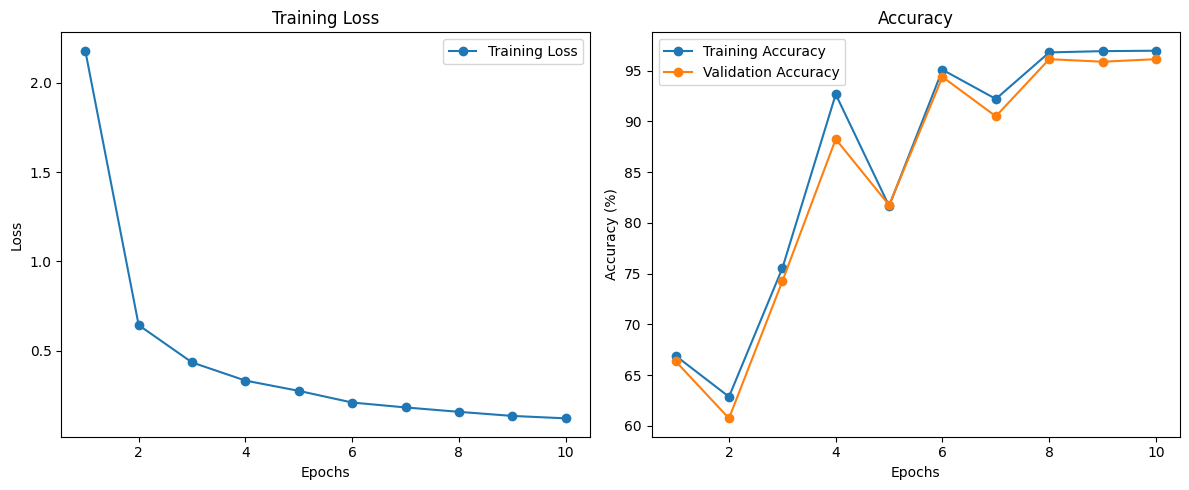

In [ ]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss', marker='o')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

**Evaluación del Modelo: Reporte de Clasificación y Matriz de Confusión**  


*   Reporte de Clasificación: Se genera un informe detallado de las métricas de evaluación del modelo, como la precisión, la recuperación (recall) y la puntuación F1, para cada clase en el conjunto de prueba.

*   Matriz de Confusión: Se calcula y visualiza una matriz de confusión para mostrar la relación entre las etiquetas reales y las predicciones realizadas por el modelo. Esto ayuda a identificar las clases que el modelo clasifica correctamente y las que confunde.



Reporte de clasificación:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       100
           1     0.9899    0.9800    0.9849       100
           2     1.0000    0.9900    0.9950       100
           3     0.9900    0.9900    0.9900       100
           4     0.9694    0.9500    0.9596       100
           5     0.9897    0.9600    0.9746       100
           6     0.9583    0.9200    0.9388       100
           7     0.8829    0.9800    0.9289       100

    accuracy                         0.9712       800
   macro avg     0.9725    0.9712    0.9715       800
weighted avg     0.9725    0.9712    0.9715       800



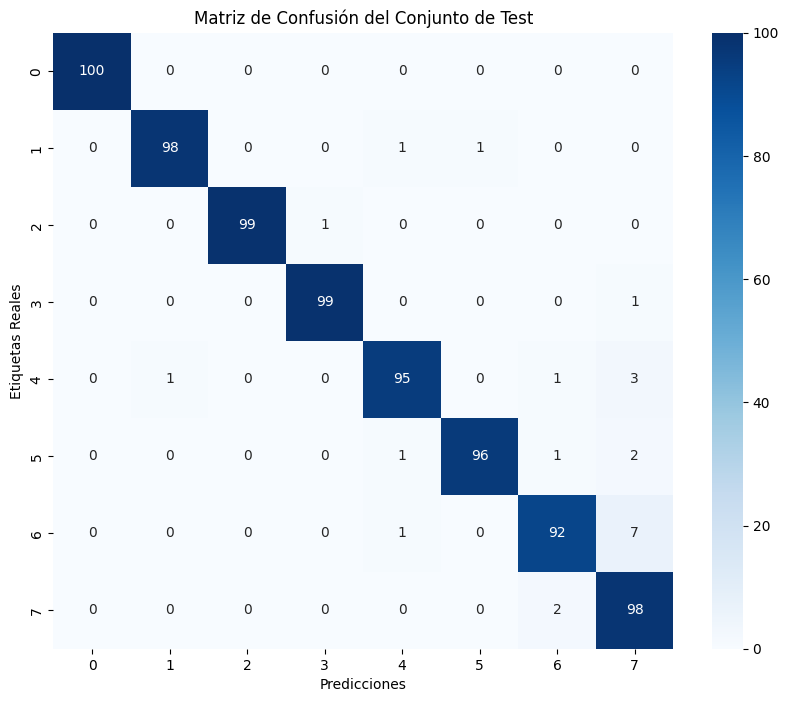

In [ ]:
print("Reporte de clasificación:")
print(classification_report(etiquetas_reales_totales, predicciones_totales, digits=4))

matriz_confusion_test = confusion_matrix(etiquetas_reales_totales, predicciones_totales)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusion_test, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas Reales')
plt.title('Matriz de Confusión del Conjunto de Test')
plt.show()

**Optimización de Hiperparámetros con Optuna para una Red Neuronal Convolucional (Opcional)**  
Este código utiliza Optuna para realizar la optimización de hiperparámetros de una red neuronal convolucional. A través de la clase ConvNet, se ajustan parámetros clave como el número de filtros en cada capa convolucional, la tasa de abandono (dropout), la tasa de aprendizaje y la regularización mediante weight decay

In [ ]:
class ConvNet(nn.Module):
    def __init__(self, trial):
        super(ConvNet, self).__init__()
        n_filters1 = trial.suggest_int('n_filters1', 16, 64, step=16)
        n_filters2 = trial.suggest_int('n_filters2', 32, 128, step=32)
        n_filters3 = trial.suggest_int('n_filters3', 64, 256, step=64)
        n_filters4 = trial.suggest_int('n_filters4', 128, 512, step=128)
        dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
        lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
        weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-3)

        self.conv1 = nn.Conv2d(3, n_filters1, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm2d(n_filters1)
        self.conv2 = nn.Conv2d(n_filters1, n_filters2, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm2d(n_filters2)
        self.conv3 = nn.Conv2d(n_filters2, n_filters3, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(n_filters3)
        self.conv4 = nn.Conv2d(n_filters3, n_filters4, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(n_filters4)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(dropout_rate)

        self.fc1_input_dim = n_filters4 * 6 * 6
        self.fc1 = nn.Linear(self.fc1_input_dim, 512)
        self.fc2 = nn.Linear(512, 8)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(-1, self.fc1_input_dim)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


def train_model(trial):
    model = ConvNet(trial).to(device)
    optimizer = optim.Adam(model.parameters(), lr=trial.suggest_loguniform('lr', 1e-4, 1e-2),
                           weight_decay=trial.suggest_loguniform('weight_decay', 1e-5, 1e-3))
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(10):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        scheduler.step()

    val_accuracy = calculate_accuracy(valid_loader, model)
    return val_accuracy


def calculate_accuracy(loader, model):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


device = 'cuda' if torch.cuda.is_available() else 'cpu'
study = optuna.create_study(direction='maximize')
study.optimize(train_model, n_trials=15)

print("Mejores hiperparámetros:")
print(study.best_params)


[I 2025-01-02 11:50:05,233] A new study created in memory with name: no-name-b097141a-8278-4bd6-9761-ff95a3b216bc
<ipython-input-10-d4aac229b2d3>:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
<ipython-input-10-d4aac229b2d3>:10: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-3)
<ipython-input-10-d4aac229b2d3>:42: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  optimizer = optim.Adam(model.parameters(),

Mejores hiperparámetros:
{'n_filters1': 32, 'n_filters2': 32, 'n_filters3': 128, 'n_filters4': 512, 'dropout_rate': 0.37966214763769723, 'lr': 0.0005773865230875181, 'weight_decay': 0.00022822884318720395}


**Entrenamiento de un modelo de red neuronal convolucional utilizando Optuna y Early Stopping**  

El código realiza una optimización automática de los hiperparámetros de un modelo de red neuronal convolucional (CNN) usando Optuna. Optuna busca los mejores valores para parámetros como el número de filtros en las capas convolucionales, la tasa de aprendizaje y la tasa de abandono (dropout). Una vez encontrados los mejores hiperparámetros, se utiliza el modelo para entrenar y evaluar su rendimiento, aplicando EarlyStopping para detener el entrenamiento si no se observan mejoras en la validación, evitando así el sobreajuste. Finalmente, se mide la precisión del modelo en el conjunto de prueba.


In [ ]:
# Aquí se asume que el modelo ConvNet ya está definido como en el código anterior
# Recuperar los mejores hiperparámetros de Optuna
best_params = study.best_params
print("Mejores hiperparámetros de Optuna:", best_params)

# Definir el modelo con los mejores hiperparámetros
class ConvNet(nn.Module):
    def __init__(self, best_params):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=best_params['n_filters1'], kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv2d(in_channels=best_params['n_filters1'], out_channels=best_params['n_filters2'], kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv2d(in_channels=best_params['n_filters2'], out_channels=best_params['n_filters3'], kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=best_params['n_filters3'], out_channels=best_params['n_filters4'], kernel_size=3, stride=1, padding=1)

        self.bn1 = nn.BatchNorm2d(best_params['n_filters1'])
        self.bn2 = nn.BatchNorm2d(best_params['n_filters2'])
        self.bn3 = nn.BatchNorm2d(best_params['n_filters3'])
        self.bn4 = nn.BatchNorm2d(best_params['n_filters4'])

        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        self.fc1 = nn.Linear(best_params['n_filters4'] * 6 * 6, 512)
        self.fc2 = nn.Linear(512, 8)

        self.dropout = nn.Dropout(p=best_params['dropout_rate'])

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool1(F.relu(self.bn2(self.conv2(x))))
        x = self.pool1(F.relu(self.bn3(self.conv3(x))))
        x = self.pool1(F.relu(self.bn4(self.conv4(x))))
        x = x.view(-1, self.fc1.in_features)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


# Cargar el mejor modelo con los parámetros óptimos de Optuna
model = ConvNet(best_params).to(device)

# Configuración de optimizador, criterio y scheduler con los mejores parámetros
optimizer = optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)
criterio = nn.CrossEntropyLoss()

# EarlyStopping
early_stopping = EarlyStopping(patience=5, delta=0.01)

# Entrenamiento del modelo
epochs = 10
train_losses = []
train_accuracies = []
val_accuracies = []

for e in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterio(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()

    train_accuracy = calculate_accuracy(train_loader, model)
    val_accuracy = calculate_accuracy(valid_loader, model)
    val_loss = running_loss / len(train_loader)

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f'Epoch: {e+1}, Loss: {running_loss / len(train_loader):.4f}, '
          f'Train Accuracy: {train_accuracy:.2f}%, Validation Accuracy: {val_accuracy:.2f}%')

    # Comprobamos si el EarlyStopping debe detener el entrenamiento
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Parada anticipada")
        model.load_state_dict(early_stopping.best_model_wts)
        break

# Evaluación del modelo en el conjunto de prueba
model.eval()
correctas = 0
total = 0
predicciones_totales = []
etiquetas_reales_totales = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicciones = torch.max(outputs, 1)
        predicciones_totales.extend(predicciones.cpu().numpy())
        etiquetas_reales_totales.extend(labels.cpu().numpy())
        total += labels.size(0)
        correctas += (predicciones == labels).sum().item()

exactitud_test = 100 * correctas / total
print(f'Exactitud del modelo en el conjunto de prueba: {exactitud_test:.2f}%')


Mejores hiperparámetros de Optuna: {'n_filters1': 32, 'n_filters2': 32, 'n_filters3': 128, 'n_filters4': 512, 'dropout_rate': 0.37966214763769723, 'lr': 0.0005773865230875181, 'weight_decay': 0.00022822884318720395}
Epoch: 1, Loss: 2.5398, Train Accuracy: 54.88%, Validation Accuracy: 55.00%
Epoch: 2, Loss: 0.6917, Train Accuracy: 60.75%, Validation Accuracy: 60.62%
Epoch: 3, Loss: 0.4561, Train Accuracy: 80.46%, Validation Accuracy: 79.12%
Epoch: 4, Loss: 0.3677, Train Accuracy: 82.12%, Validation Accuracy: 80.38%
Epoch: 5, Loss: 0.2848, Train Accuracy: 82.38%, Validation Accuracy: 81.12%
Epoch: 6, Loss: 0.2384, Train Accuracy: 96.42%, Validation Accuracy: 94.88%
Epoch: 7, Loss: 0.1831, Train Accuracy: 94.67%, Validation Accuracy: 93.00%
Epoch: 8, Loss: 0.1582, Train Accuracy: 95.88%, Validation Accuracy: 94.75%
Epoch: 9, Loss: 0.1435, Train Accuracy: 93.00%, Validation Accuracy: 90.62%
Epoch: 10, Loss: 0.1523, Train Accuracy: 96.88%, Validation Accuracy: 95.88%
Exactitud del modelo en

**Entrenamiento y Evaluación de VGG16 para Clasificación de Imágenes (Opcional)**  
Este código adapta el modelo preentrenado VGG16 para realizar clasificación en un conjunto de datos específico. Primero, se congela la mayoría de los parámetros de la red, excepto la capa final, que se ajusta para tener el número de clases del conjunto de datos. El modelo se entrena utilizando el optimizador Adam y la función de pérdida CrossEntropyLoss. Se calcula la precisión del modelo en cada época, y después se evalúa en los conjuntos de validación y prueba para obtener las precisiones correspondientes.

In [ ]:
vgg16 = models.vgg16(pretrained=True)

for param in vgg16.parameters():
    param.requires_grad = False

num_classes = len(train_data.classes)
vgg16.classifier[6] = nn.Linear(vgg16.classifier[6].in_features, num_classes)

# Mover el modelo a GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vgg16 = vgg16.to(device)

# Definir el optimizador y la función de pérdida
optimizer = torch.optim.Adam(vgg16.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Entrenamiento del modelo
num_epochs = 10
for epoch in range(num_epochs):
    vgg16.train()  # Establecer el modelo en modo de entrenamiento
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero los gradientes
        optimizer.zero_grad()

        # Forward pass
        outputs = vgg16(inputs)
        loss = criterion(outputs, labels)

        # Backward pass y optimización
        loss.backward()
        optimizer.step()

        # Estadísticas
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calcular la precisión en cada epoch
    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {accuracy:.2f}%")

# Evaluación del modelo en el conjunto de validación
vgg16.eval()  # Establecer el modelo en modo de evaluación
correct = 0
total = 0

with torch.no_grad():  # No calcular gradientes durante la evaluación
    for inputs, labels in valid_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = vgg16(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy = 100 * correct / total
print(f"Validation Accuracy: {val_accuracy:.2f}%")

# Evaluación en el conjunto de prueba
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = vgg16(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/10], Loss: 1.1189, Accuracy: 61.54%
Epoch [2/10], Loss: 0.6661, Accuracy: 77.46%
Epoch [3/10], Loss: 0.5633, Accuracy: 80.75%
Epoch [4/10], Loss: 0.5453, Accuracy: 81.92%
Epoch [5/10], Loss: 0.5236, Accuracy: 81.46%
Epoch [6/10], Loss: 0.4858, Accuracy: 83.50%
Epoch [7/10], Loss: 0.4977, Accuracy: 82.50%
Epoch [8/10], Loss: 0.4727, Accuracy: 83.50%
Epoch [9/10], Loss: 0.4783, Accuracy: 83.04%
Epoch [10/10], Loss: 0.4600, Accuracy: 84.00%
Validation Accuracy: 89.12%
Test Accuracy: 89.00%
